# Pipeline EDA — Steps 0 & 1
General statistics and histograms for the shower cache (step 0) and training dataset (step 1).

In [7]:
import os, sys
import torch
import numpy as np
import matplotlib.pyplot as plt

_HERE = os.path.abspath("../")
if _HERE not in sys.path:
    sys.path.insert(0, _HERE)

from modules_v6.constants import SHOWER_CACHE, TRAINING_DATASET_FOLDER, NUM_SHOWERS
NUM_SHOWERS=50
from modules_v6.detector_strategies import _STRATEGIES

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

In [8]:
def tensor_summary(name, t):
    """Print shape, dtype, and basic stats for a tensor."""
    print(f"\n  {name}")
    print(f"    shape : {tuple(t.shape)},  dtype : {t.dtype}")
    finite = t[torch.isfinite(t)]
    n_nan = int(torch.isnan(t).sum())
    n_inf = int(torch.isinf(t).sum())
    print(f"    NaN: {n_nan}   Inf: {n_inf}")
    if finite.numel() > 0:
        print(f"    min={finite.min().item():.6g}  max={finite.max().item():.6g}  "
              f"mean={finite.mean().item():.6g}  std={finite.std().item():.6g}")
        q = torch.quantile(finite.float(), torch.tensor([0.01, 0.25, 0.5, 0.75, 0.99]))
        print(f"    quantiles [1%, 25%, 50%, 75%, 99%]: "
              f"[{q[0]:.6g}, {q[1]:.6g}, {q[2]:.6g}, {q[3]:.6g}, {q[4]:.6g}]")
    n_zero = int((t == 0).sum())
    print(f"    zeros: {n_zero}/{t.numel()} ({100*n_zero/t.numel():.1f}%)")

## Step 0 — Shower cache

In [9]:
import showerdata

cache_path = os.path.join(SHOWER_CACHE, f"cashed_showers_{NUM_SHOWERS}.pt")
print(f"Loading: {cache_path}")
data = showerdata.load(cache_path)

points = torch.as_tensor(data.points, dtype=torch.float32)
dirs   = torch.as_tensor(data.directions, dtype=torch.float32)
energ  = torch.as_tensor(data.energies, dtype=torch.float32)
pdg    = torch.as_tensor(data.pdg, dtype=torch.long)

n_showers = points.shape[0]
print(f"Number of showers: {n_showers}")
print(f"Points shape: {tuple(points.shape)}  (showers, max_pts, 5)")
print(f"Directions: {tuple(dirs.shape)},  Energies: {tuple(energ.shape)},  PDG: {tuple(pdg.shape)}")

Loading: /n/holylfs05/LABS/arguelles_delgado_lab/Everyone/zdimitrov/detector_optimization_v6/v6_run_00/cashed_showers_50.pt
Number of showers: 50
Points shape: (50, 2048, 5)  (showers, max_pts, 5)
Directions: (50, 3),  Energies: (50, 1),  PDG: (50,)


In [10]:
# Per-column statistics for shower points
col_names = ["x (North)", "y (Up)", "z (East)", "E (energy)", "t (time)"]
for c, name in enumerate(col_names):
    tensor_summary(f"points[:,:,{c}] — {name}", points[:, :, c])

# Padding fraction
pad_mask = (points.abs().sum(dim=-1) == 0)
frac_pad = pad_mask.float().mean(dim=1)
print(f"\nPadding fraction per shower: mean={frac_pad.mean():.3f}, "
      f"min={frac_pad.min():.3f}, max={frac_pad.max():.3f}")


  points[:,:,0] — x (North)
    shape : (50, 2048),  dtype : torch.float32
    NaN: 0   Inf: 0
    min=-11902.3  max=12036.8  mean=-400.967  std=5815.98
    quantiles [1%, 25%, 50%, 75%, 99%]: [-10970.2, -5084.85, -710.051, 4696.8, 10935.9]
    zeros: 3599/102400 (3.5%)

  points[:,:,1] — y (Up)
    shape : (50, 2048),  dtype : torch.float32
    NaN: 0   Inf: 0
    min=-11657.1  max=10338.5  mean=-1288.93  std=4045.56
    quantiles [1%, 25%, 50%, 75%, 99%]: [-10170, -3979.09, -1258.33, 1311.9, 7984.17]
    zeros: 3599/102400 (3.5%)

  points[:,:,2] — z (East)
    shape : (50, 2048),  dtype : torch.float32
    NaN: 0   Inf: 0
    min=0  max=23  mean=14.3114  std=5.81247
    quantiles [1%, 25%, 50%, 75%, 99%]: [0, 10, 15, 19, 23]
    zeros: 3655/102400 (3.6%)

  points[:,:,3] — E (energy)
    shape : (50, 2048),  dtype : torch.float32
    NaN: 0   Inf: 0
    min=0  max=1.09853e+08  mean=20467.3  std=577585
    quantiles [1%, 25%, 50%, 75%, 99%]: [0, 6.15972, 27.1867, 118.323, 56629.3]
 

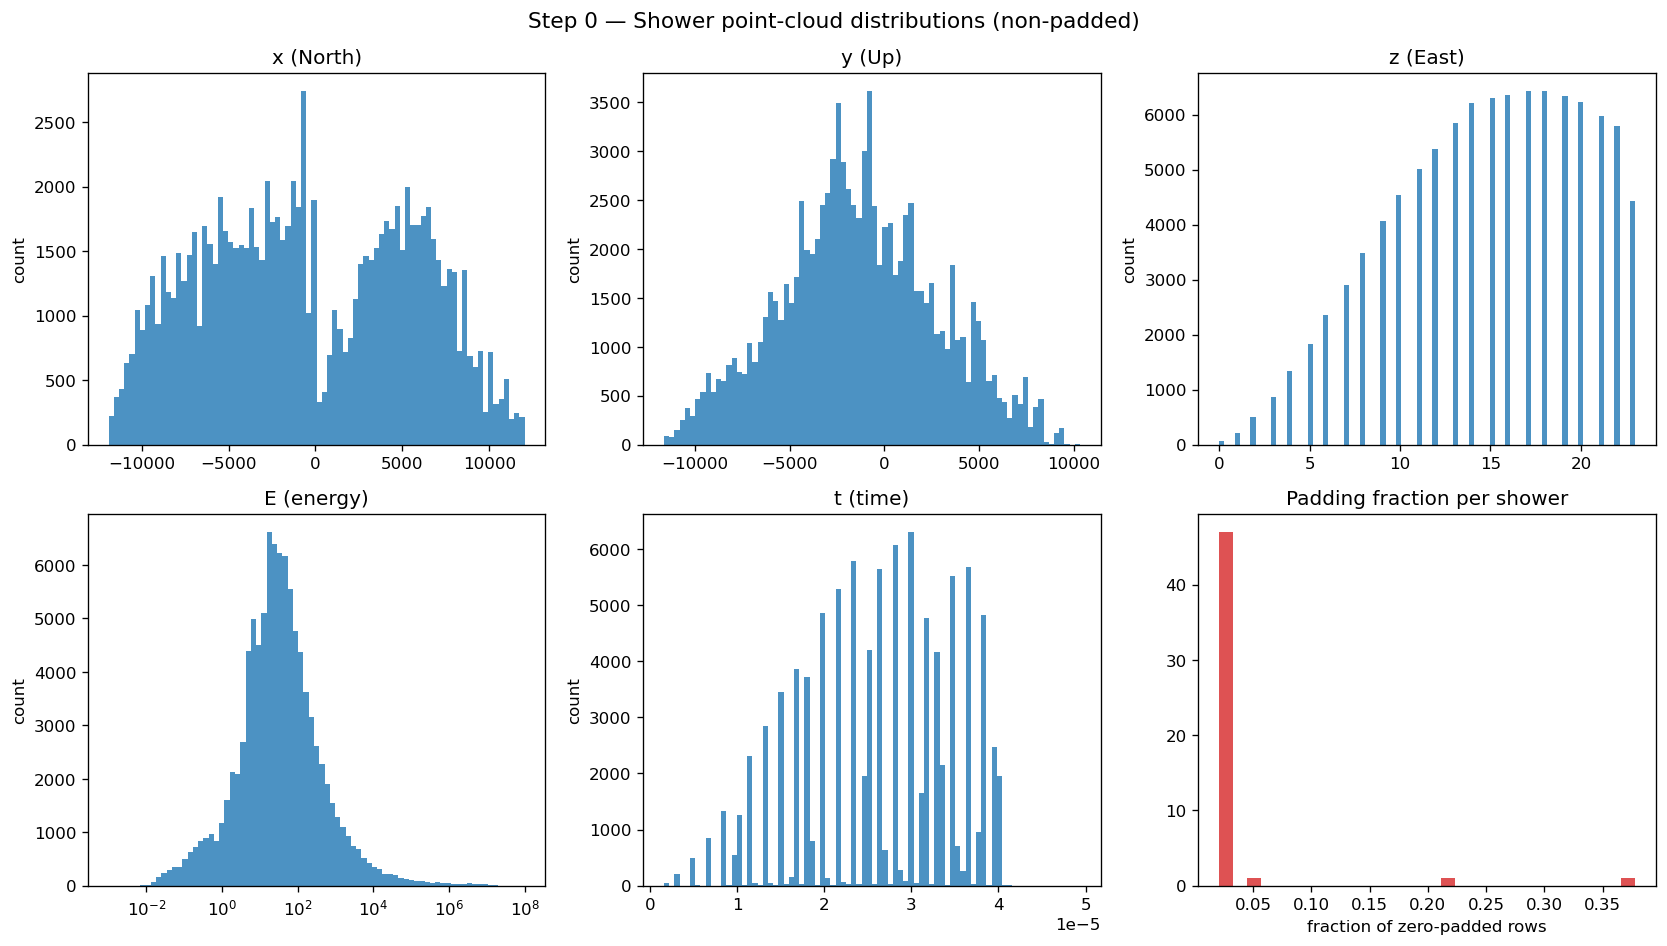

In [11]:
# Histograms of shower point-cloud columns (exclude padding rows)
non_pad = ~pad_mask  # (N, P)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for c, name in enumerate(col_names):
    ax = axes[c]
    vals = points[:, :, c][non_pad].numpy()
    if c == 3:  # energy
        ax.hist(vals, bins=np.logspace(-3, 8, 80), edgecolor="none", alpha=0.8)
        ax.set_xscale("log")
    else:
        ax.hist(vals, bins=80, edgecolor="none", alpha=0.8)
    ax.set_title(name)
    ax.set_ylabel("count")

# Padding fraction per shower
ax = axes[5]
ax.hist(frac_pad.numpy(), bins=30, edgecolor="none", alpha=0.8, color="C3")
ax.set_title("Padding fraction per shower")
ax.set_xlabel("fraction of zero-padded rows")

fig.suptitle("Step 0 — Shower point-cloud distributions (non-padded)", fontsize=13)
fig.tight_layout()
plt.show()

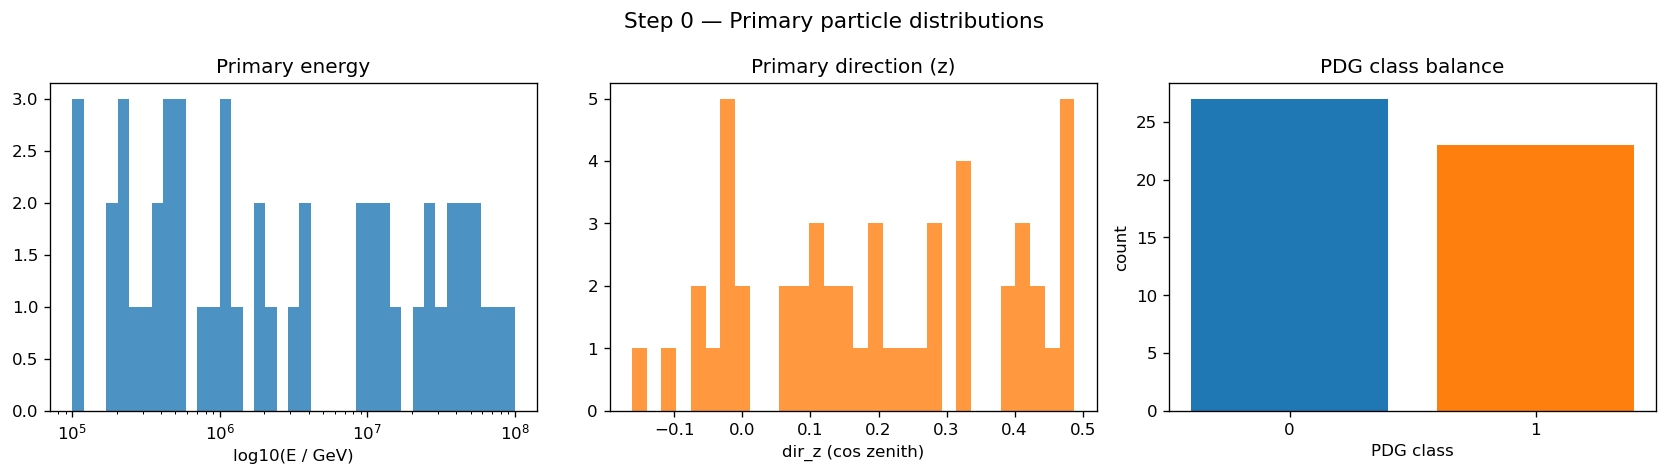

Direction norms — min=1  max=1


In [12]:
# Primary particle properties
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Energy distribution
ax = axes[0]
ax.hist(energ, bins=np.logspace(5, 8, 40), edgecolor="none", alpha=0.8)
ax.set_xscale("log")
ax.set_xlabel("log10(E / GeV)")
ax.set_title("Primary energy")

# Direction: cos(zenith) = dir_z
ax = axes[1]
ax.hist(dirs[:, 2].numpy(), bins=30, edgecolor="none", alpha=0.8, color="C1")
ax.set_xlabel("dir_z (cos zenith)")
ax.set_title("Primary direction (z)")

# PDG class balance
ax = axes[2]
vals, counts = pdg.unique(return_counts=True)
ax.bar(vals.numpy().astype(str), counts.numpy(), color=["C0", "C1"])
ax.set_xlabel("PDG class")
ax.set_ylabel("count")
ax.set_title("PDG class balance")

fig.suptitle("Step 0 — Primary particle distributions", fontsize=13)
fig.tight_layout()
plt.show()

# Direction norms (sanity check)
norms = dirs.norm(dim=1)
print(f"Direction norms — min={norms.min():.6g}  max={norms.max():.6g}")

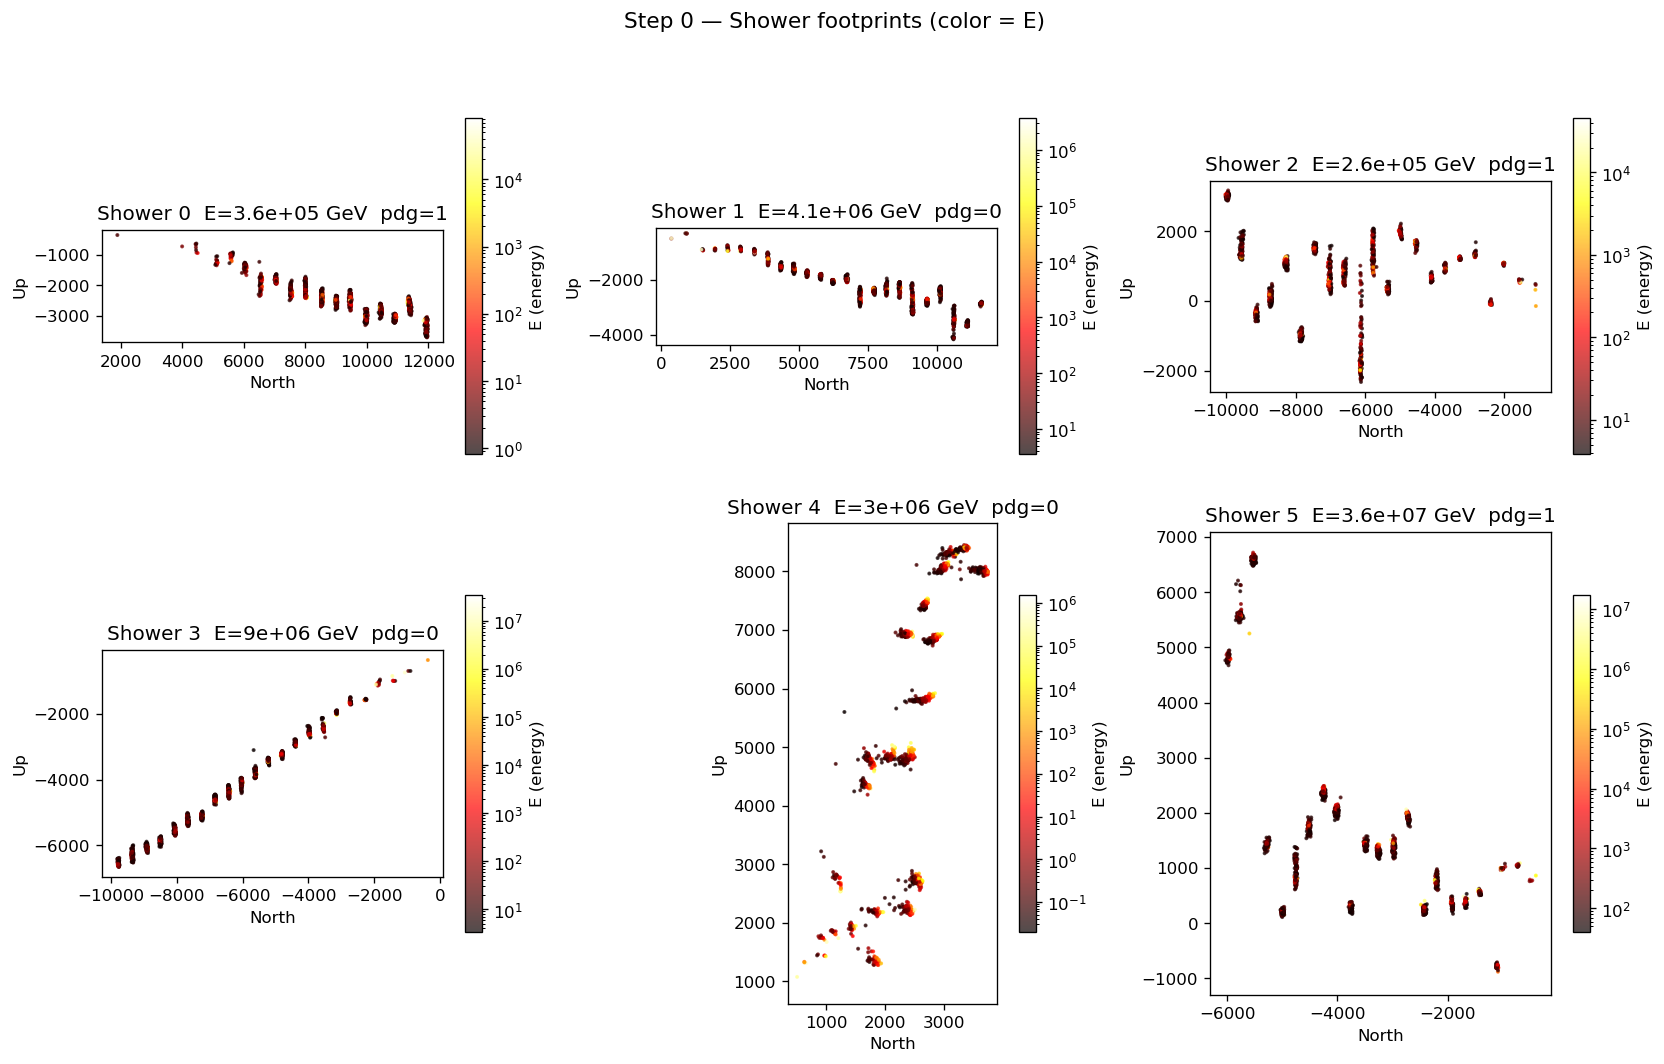

In [13]:
from matplotlib.colors import LogNorm
# 2D scatter: shower footprints (first 6 showers)
n_show = min(6, n_showers)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i in range(n_show):
    ax = axes[i]
    mask = ~pad_mask[i]
    x = points[i, mask, 0].numpy()
    y = points[i, mask, 1].numpy()
    e = points[i, mask, 3].numpy()   # col 3 = E (energy)
    sc = ax.scatter(x, y, c=e, s=2, cmap="hot", alpha=0.7,
                  norm=LogNorm(vmin=e[e > 0].min(), vmax=e.max()))    
    ax.set_title(f"Shower {i}  E={energ[i,0]:.2g} GeV  pdg={pdg[i]}")
    ax.set_xlabel("North")
    ax.set_ylabel("Up")
    ax.set_aspect("equal")
    plt.colorbar(sc, ax=ax, label="E (energy)", shrink=0.7)

fig.suptitle("Step 0 — Shower footprints (color = E)", fontsize=13)
fig.tight_layout()
plt.show()

## Step 1 — Training dataset

In [14]:
primary = torch.load(os.path.join(TRAINING_DATASET_FOLDER, "primary.pt"),
                     map_location="cpu", weights_only=True)
xy      = torch.load(os.path.join(TRAINING_DATASET_FOLDER, "xy.pt"),
                     map_location="cpu", weights_only=True)
E       = torch.load(os.path.join(TRAINING_DATASET_FOLDER, "E.pt"),
                     map_location="cpu", weights_only=True)
T_e      = torch.load(os.path.join(TRAINING_DATASET_FOLDER, "T.pt"),
                     map_location="cpu", weights_only=True)
strat   = torch.load(os.path.join(TRAINING_DATASET_FOLDER, "strategy_ids.pt"),
                     map_location="cpu", weights_only=True)
stats   = torch.load(os.path.join(TRAINING_DATASET_FOLDER, "norm_stats.pt"),
                     map_location="cpu", weights_only=True)

N_pairs = primary.shape[0]
print(f"Total training pairs: {N_pairs}")
print(f"primary: {tuple(primary.shape)},  xy: {tuple(xy.shape)}")
print(f"E: {tuple(E.shape)},  T: {tuple(T.shape)},  strat: {tuple(strat.shape)}")

Total training pairs: 3500000
primary: (3500000, 5),  xy: (3500000, 100, 2)


NameError: name 'T' is not defined

In [15]:
# Primary feature statistics
prim_names = ["dir_x", "dir_y", "dir_z", "log10(E/1e5)", "pdg"]
for c, name in enumerate(prim_names):
    tensor_summary(f"primary[:,{c}] — {name}", primary[:, c])


  primary[:,0] — dir_x
    shape : (3500000,),  dtype : torch.float32
    NaN: 0   Inf: 0
    min=-1  max=0.999999  mean=-0.0185795  std=0.676584


    quantiles [1%, 25%, 50%, 75%, 99%]: [-0.993149, -0.690926, -0.0291975, 0.650508, 0.988323]
    zeros: 0/3500000 (0.0%)

  primary[:,1] — dir_y
    shape : (3500000,),  dtype : torch.float32
    NaN: 0   Inf: 0
    min=-0.999999  max=1  mean=-0.00106532  std=0.688906
    quantiles [1%, 25%, 50%, 75%, 99%]: [-0.993261, -0.689238, -0.0267669, 0.690053, 0.993084]
    zeros: 0/3500000 (0.0%)

  primary[:,2] — dir_z
    shape : (3500000,),  dtype : torch.float32
    NaN: 0   Inf: 0
    min=-0.173646  max=0.499999  mean=0.169859  std=0.196074
    quantiles [1%, 25%, 50%, 75%, 99%]: [-0.166793, -0.000443961, 0.173601, 0.341755, 0.493819]
    zeros: 0/3500000 (0.0%)

  primary[:,3] — log10(E/1e5)
    shape : (3500000,),  dtype : torch.float32
    NaN: 0   Inf: 0
    min=7.94729e-07  max=0.999996  mean=0.50013  std=0.288997
    quantiles [1%, 25%, 50%, 75%, 99%]: [0.00985207, 0.249825, 0.500473, 0.751135, 0.990057]
    zeros: 0/3500000 (0.0%)

  primary[:,4] — pdg
    shape : (3500000,),  dt

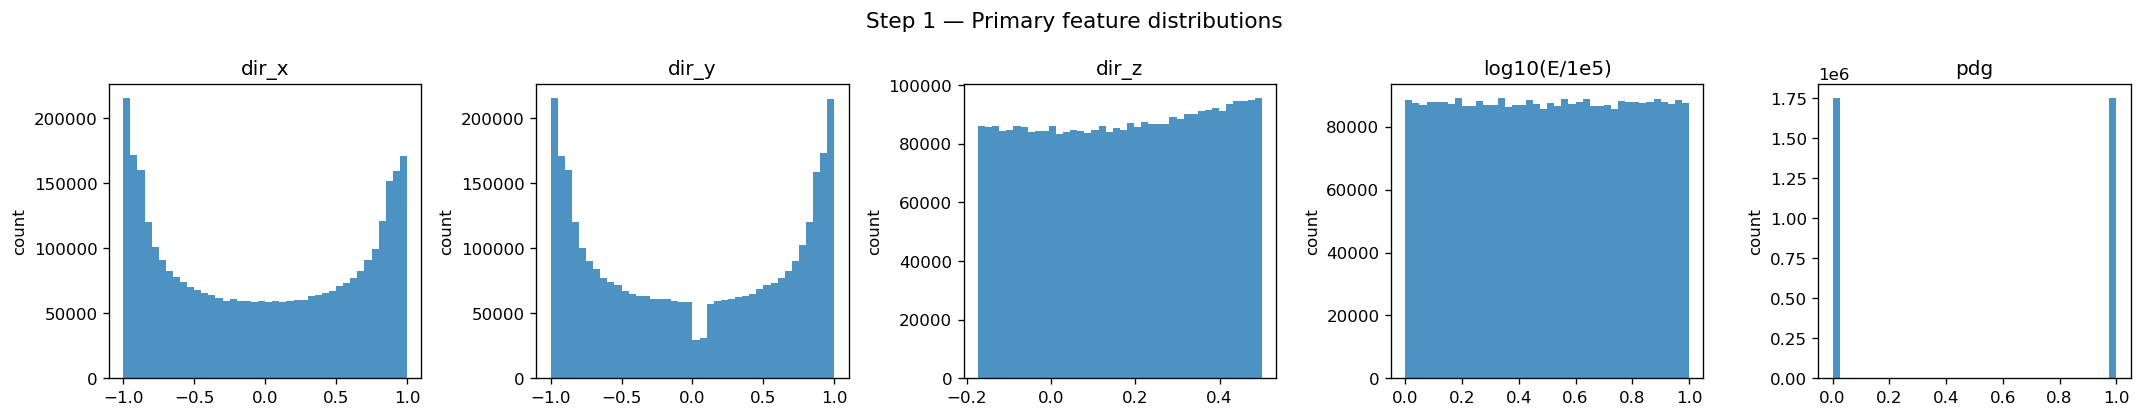

In [16]:
# Histograms of primary features
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for c, (name, ax) in enumerate(zip(prim_names, axes)):
    vals = primary[:, c].numpy()
    ax.hist(vals, bins=40, edgecolor="none", alpha=0.8)
    ax.set_title(name)
    ax.set_ylabel("count")
fig.suptitle("Step 1 — Primary feature distributions", fontsize=13)
fig.tight_layout()
plt.show()

In [17]:
# Detector layout statistics
tensor_summary("xy[:,:,0] — North", xy[:, :, 0])
tensor_summary("xy[:,:,1] — Up", xy[:, :, 1])

spread_n = xy[:, :, 0].std(dim=1)
spread_u = xy[:, :, 1].std(dim=1)
print(f"\nPer-sample detector spread (std across 100 dets):")
print(f"  North — mean={spread_n.mean():.1f}  min={spread_n.min():.1f}  max={spread_n.max():.1f}")
print(f"  Up    — mean={spread_u.mean():.1f}  min={spread_u.min():.1f}  max={spread_u.max():.1f}")


  xy[:,:,0] — North
    shape : (3500000, 100),  dtype : torch.float32
    NaN: 0   Inf: 0
    min=-2607.87  max=2583.82  mean=22.9681  std=855.135


RuntimeError: quantile() input tensor is too large

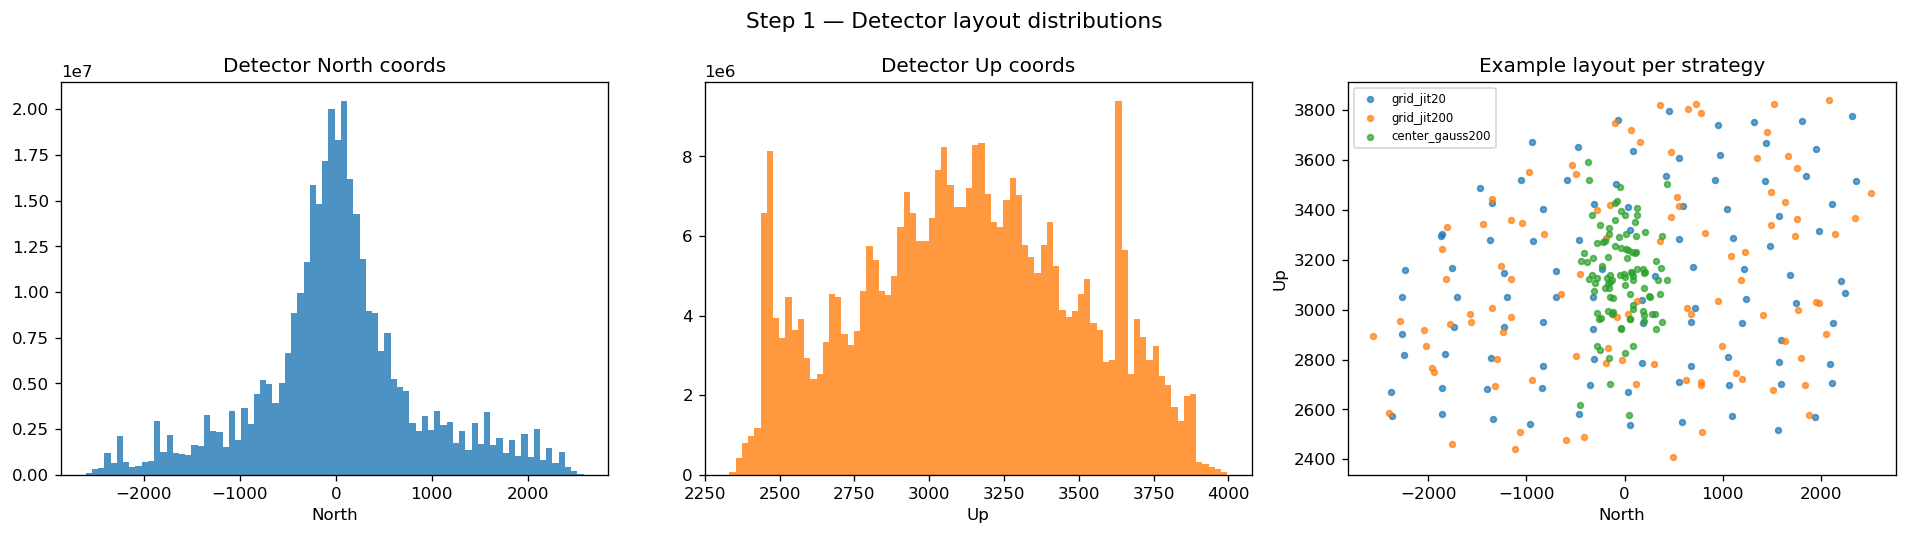

In [18]:
# Detector layout histograms + scatter by strategy
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(xy[:, :, 0].flatten().numpy(), bins=80, edgecolor="none", alpha=0.8)
axes[0].set_title("Detector North coords")
axes[0].set_xlabel("North")

axes[1].hist(xy[:, :, 1].flatten().numpy(), bins=80, edgecolor="none", alpha=0.8, color="C1")
axes[1].set_title("Detector Up coords")
axes[1].set_xlabel("Up")

# Scatter one sample per strategy
ax = axes[2]
strat_names = [s[0] for s in _STRATEGIES]
for sid in sorted(strat.unique().tolist()):
    if sid > 2:  # only plot first 4 strategies for clarity
        continue
    idx = (strat == sid).nonzero(as_tuple=True)[0][0]  # first sample
    ax.scatter(xy[idx, :, 0].numpy(), xy[idx, :, 1].numpy(),
               s=12, alpha=0.7, label=strat_names[sid])
ax.set_xlabel("North")
ax.set_ylabel("Up")
ax.set_aspect("auto")
ax.set_title("Example layout per strategy")
ax.legend(fontsize=7)

fig.suptitle("Step 1 — Detector layout distributions", fontsize=13)
fig.tight_layout()
plt.show()

In [ ]:
# E and T label statistics
tensor_summary("E  (N, n_det)", E)
tensor_summary("T  (N, n_det)", T_e)

e_per_sample = E.sum(dim=1)
print(f"\nTotal E per sample — mean={e_per_sample.mean():.4g}  "
      f"std={e_per_sample.std():.4g}  min={e_per_sample.min():.4g}  max={e_per_sample.max():.4g}")

n_all_zero_E = int((E.abs().sum(dim=1) == 0).sum())
n_all_zero_T = int((T_e.abs().sum(dim=1) == 0).sum())
print(f"Samples with ALL zero E: {n_all_zero_E}/{N_pairs} ({100*n_all_zero_E/N_pairs:.1f}%)")
print(f"Samples with ALL zero T: {n_all_zero_T}/{N_pairs} ({100*n_all_zero_T/N_pairs:.1f}%)")

det_hit_frac = (E.abs() > 0).float().mean(dim=1)
print(f"Fraction of detectors hit per sample — "
      f"mean={det_hit_frac.mean():.3f}  min={det_hit_frac.min():.3f}  max={det_hit_frac.max():.3f}")


  E  (N, n_det)
    shape : (250, 100),  dtype : torch.float32
    NaN: 0   Inf: 0
    min=0  max=6.78388e+06  mean=4457.3  std=98404.4
    quantiles [1%, 25%, 50%, 75%, 99%]: [0, 0, 0, 0, 8506.64]
    zeros: 20447/25000 (81.8%)

  T  (N, n_det)
    shape : (250, 100),  dtype : torch.float32
    NaN: 0   Inf: 0
    min=0  max=5.98077e-07  mean=6.97446e-10  std=1.1604e-08
    quantiles [1%, 25%, 50%, 75%, 99%]: [0, 0, 0, 0, 4.44845e-09]
    zeros: 21080/25000 (84.3%)

Total E per sample — mean=4.457e+05  std=2.253e+06  min=0  max=1.729e+07
Samples with ALL zero E: 146/250 (58.4%)
Samples with ALL zero T: 157/250 (62.8%)
Fraction of detectors hit per sample — mean=0.182  min=0.000  max=1.000


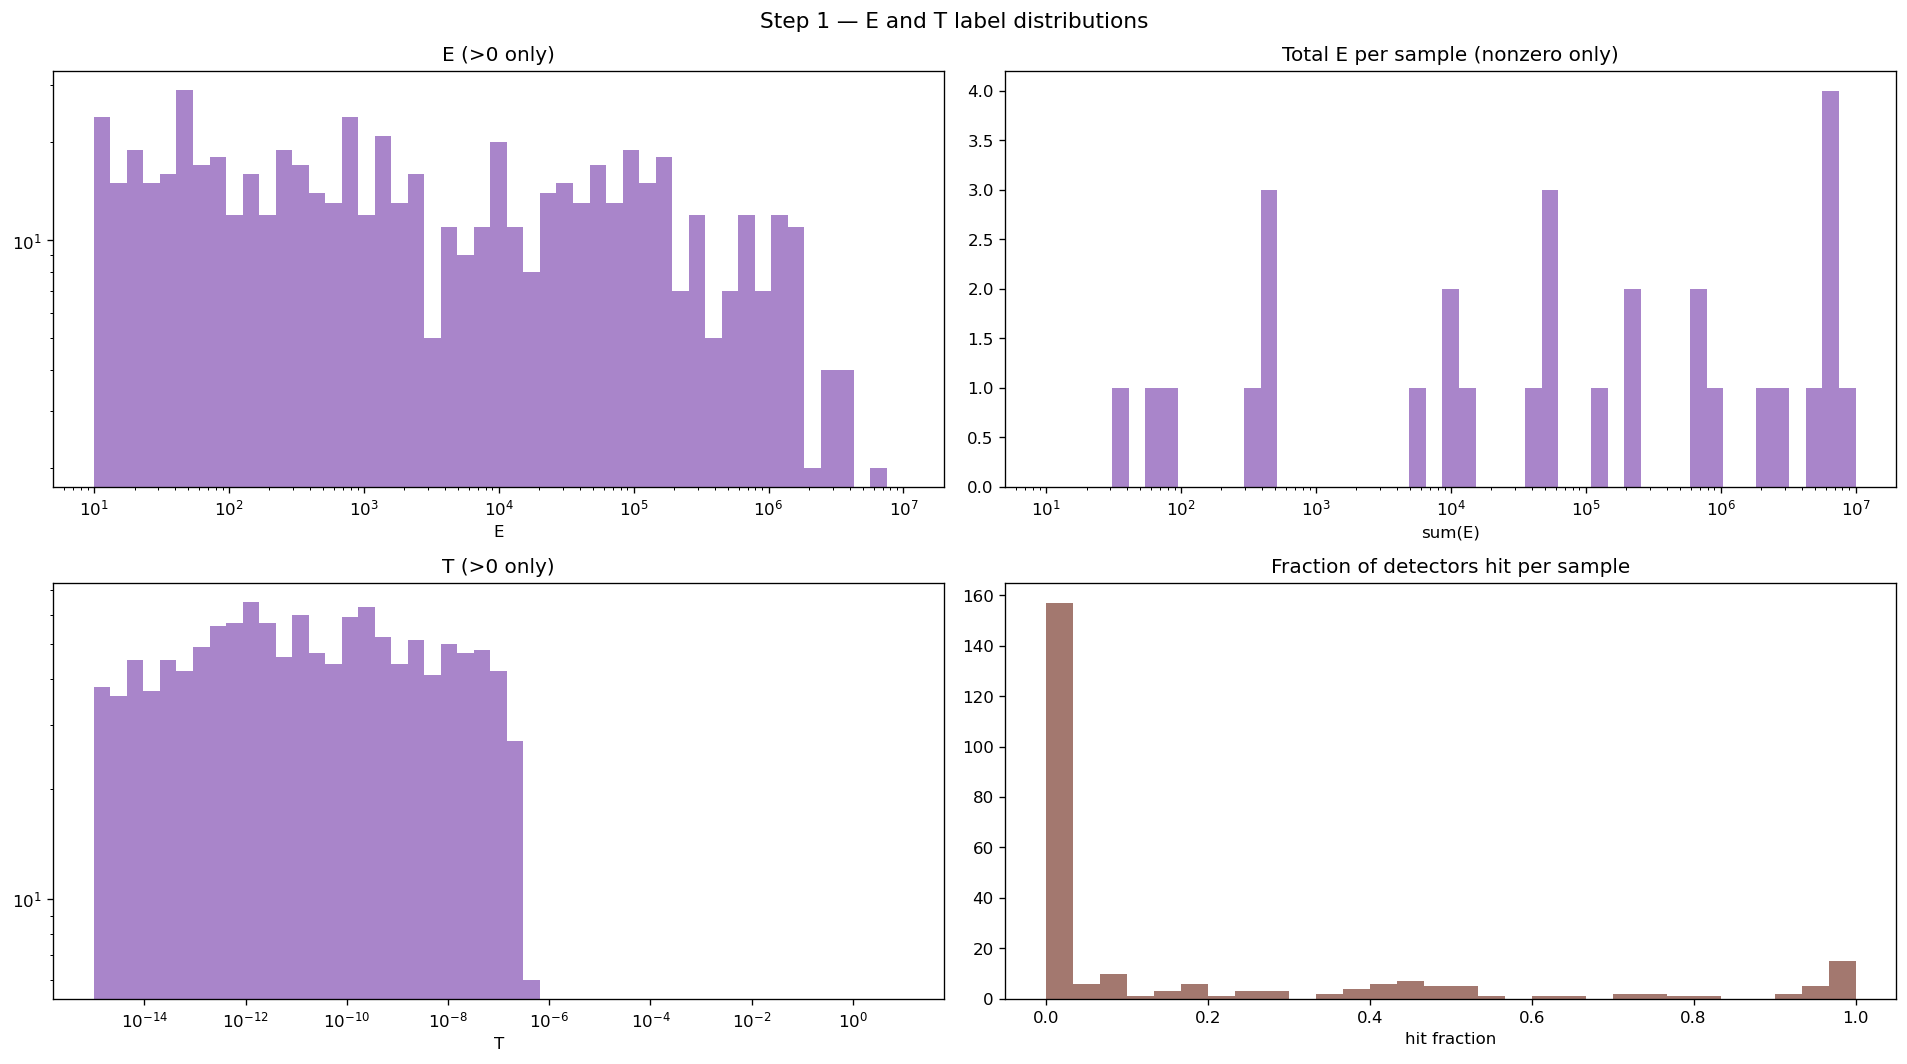

In [ ]:
# E and T histograms
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# E — all values
ax = axes[0, 0]
e_flat = E.flatten().numpy()
ax.hist(e_flat[e_flat > 0], bins=np.logspace(1, 7, 50), edgecolor="none", alpha=0.8, color="C4")
ax.set_xscale("log")
ax.set_title("E (>0 only)")
ax.set_xlabel("E")
ax.set_yscale("log")

# E — total per sample
ax = axes[0, 1]
e_sum = E.sum(dim=1).numpy()
ax.hist(e_sum[e_sum > 0], bins=np.logspace(1, 7, 50), edgecolor="none", alpha=0.8, color="C4")
ax.set_xscale("log")
ax.set_title("Total E per sample (nonzero only)")
ax.set_xlabel("sum(E)")

# T — all values
ax = axes[1, 0]
t_flat = T_e.flatten().numpy()
ax.hist(t_flat[t_flat > 0], bins=np.logspace(-15, 1, 50), edgecolor="none", alpha=0.8, color="C4")
ax.set_xscale("log")
ax.set_title("T (>0 only)")
ax.set_xlabel("T")
ax.set_yscale("log")

# Hit fraction per sample
ax = axes[1, 1]
ax.hist(det_hit_frac.numpy(), bins=30, edgecolor="none", alpha=0.8, color="C5")
ax.set_title("Fraction of detectors hit per sample")
ax.set_xlabel("hit fraction")

fig.suptitle("Step 1 — E and T label distributions", fontsize=13)
fig.tight_layout()
plt.show()

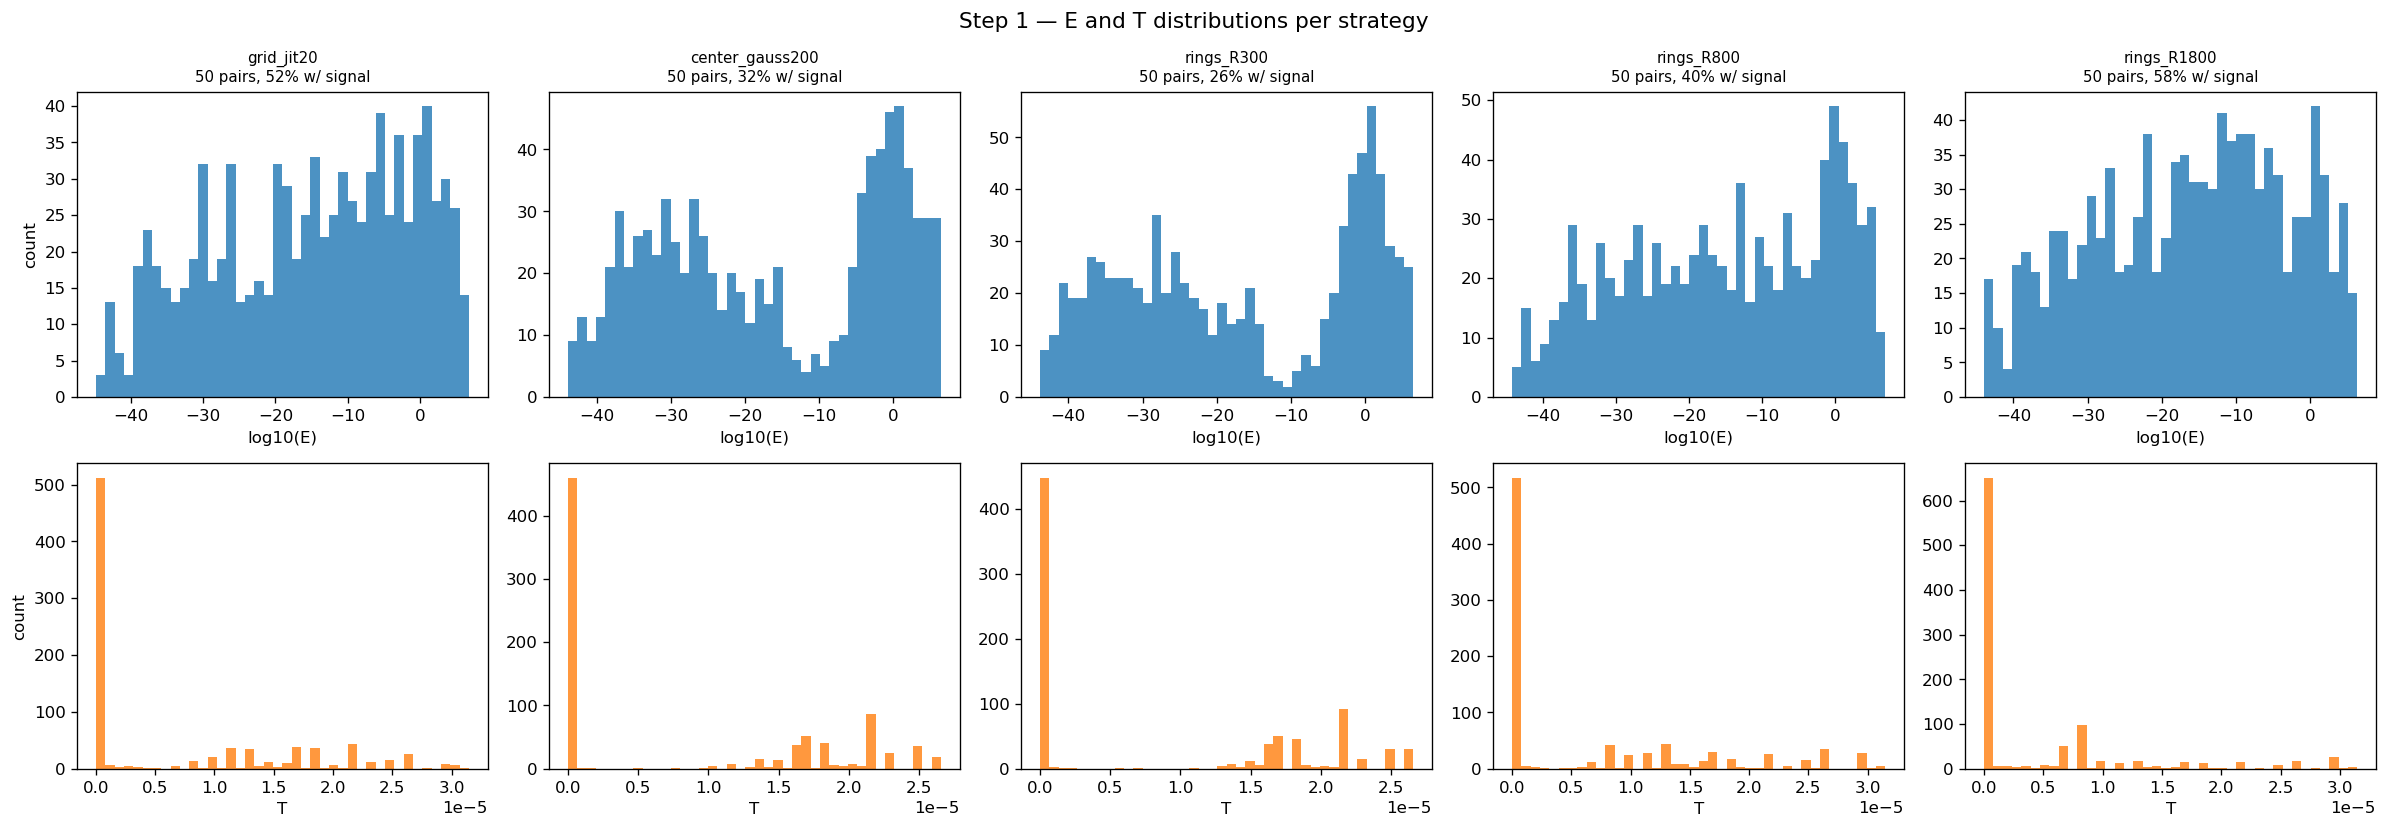

In [ ]:
# Strategy breakdown — E distribution per strategy
strat_names = [s[0] for s in _STRATEGIES]
n_strat = len(strat.unique())

fig, axes = plt.subplots(2, n_strat, figsize=(4 * n_strat, 7))

for i, sid in enumerate(sorted(strat.unique().tolist())):
    mask = strat == sid
    name = strat_names[sid] if sid < len(strat_names) else f"strat_{sid}"
    e_sub = E[mask]
    t_sub = T[mask]
    n = int(mask.sum())
    nonzero_frac = (e_sub.abs().sum(dim=1) > 0).float().mean()

    # E histogram (nonzero)
    ax = axes[0, i]
    e_nz = e_sub[e_sub > 0].numpy()
    if len(e_nz) > 0:
        ax.hist(np.log10(e_nz), bins=40, edgecolor="none", alpha=0.8)
    ax.set_title(f"{name}\n{n} pairs, {100*nonzero_frac:.0f}% w/ signal", fontsize=9)
    ax.set_xlabel("log10(E)")
    if i == 0:
        ax.set_ylabel("count")

    # T histogram (nonzero)
    ax = axes[1, i]
    t_nz = t_sub[t_sub > 0].numpy()
    if len(t_nz) > 0:
        ax.hist(t_nz, bins=40, edgecolor="none", alpha=0.8, color="C1")
    ax.set_xlabel("T")
    if i == 0:
        ax.set_ylabel("count")

fig.suptitle("Step 1 — E and T distributions per strategy", fontsize=13)
fig.tight_layout()
plt.show()

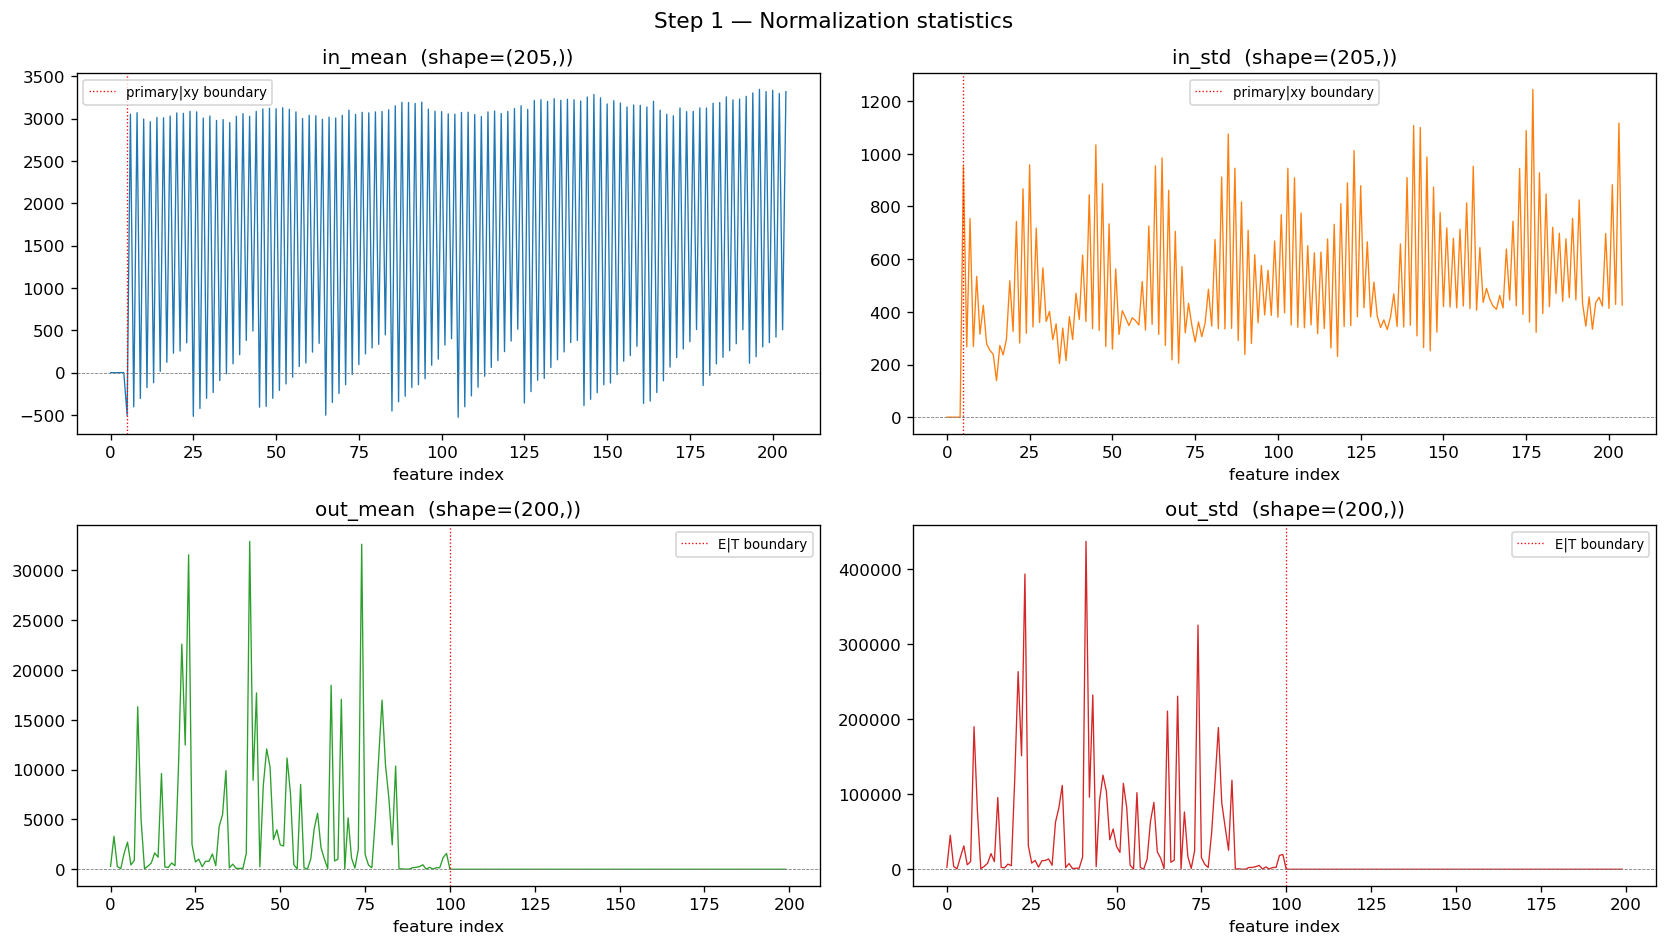

In [ ]:
# Normalization stats overview
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
stat_keys = ["in_mean", "in_std", "out_mean", "out_std"]
colors = ["C0", "C1", "C2", "C3"]

for ax, key, c in zip(axes.flatten(), stat_keys, colors):
    v = stats[key].numpy()
    ax.plot(v, linewidth=0.8, color=c)
    ax.set_title(f"{key}  (shape={v.shape})")
    ax.set_xlabel("feature index")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    # mark the boundary between primary (5) and xy (200) for input stats
    if key.startswith("in"):
        ax.axvline(5, color="red", linewidth=0.8, linestyle=":", label="primary|xy boundary")
        ax.legend(fontsize=8)
    # mark E|T boundary for output stats
    if key.startswith("out"):
        ax.axvline(100, color="red", linewidth=0.8, linestyle=":", label="E|T boundary")
        ax.legend(fontsize=8)

fig.suptitle("Step 1 — Normalization statistics", fontsize=13)
fig.tight_layout()
plt.show()